# KDE Plots Testing Notebook

This notebook is for manual testing of KDE (Kernel Density Estimation) quartile plots.
It uses functions from `postprocess_functions.py` and `plot_kde_functions.py`.

In [7]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

from ddstartup.postprocessing.postprocess_functions import (
    load_h5_to_dataframe,
    get_input_parameters,
    scale_target,
    apply_filters,
    find_latest_h5_file,
    get_discrete_colorscale
)
from ddstartup.postprocessing.plot_kde_functions import kde_quartile_plot
from ddstartup.utils.tools import PARAM_UNITS

print("✅ Imports successful")

✅ Imports successful


## Configuration

In [8]:
# Configuration - specify directory or files

# Option 1: Automatic - find latest file in specified directory (DEFAULT)
outputs_dir = Path('../outputs/20251009_131829_parametric_lump')
files_to_analyze = []

latest_h5_file = find_latest_h5_file(outputs_dir)
if latest_h5_file:
    print(f"📂 Auto-detected folder: {latest_h5_file.parent.name}")
    print(f"📄 Latest file: {latest_h5_file.name}")
    files_to_analyze = [latest_h5_file]

# Option 2: Analyze all files in a specific folder
# outputs_dir = Path('../outputs/20251008_081422_parametric_T_seeded')
# files_to_analyze = sorted(outputs_dir.glob('*.h5'))
# print(f"📂 Using folder: {outputs_dir.name}")
# print(f"📄 Found {len(files_to_analyze)} file(s): {[f.name for f in files_to_analyze]}")

# Target variable to analyze
target = 't_startup'  # Change this to your desired target variable
print(f"\n🎯 Target variable: {target}")

# Load data
if not files_to_analyze:
    raise ValueError("No files to analyze. Please check the configuration.")

# Load all files and concatenate
dfs = []
for file_path in files_to_analyze:
    df_single = load_h5_to_dataframe(file_path)
    dfs.append(df_single)
    print(f"📄 Loaded {file_path.name}: shape {df_single.shape}")

df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
print(f"\n📊 Final dataframe shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

# Get input parameters
inputs = get_input_parameters(df, target)
print(f"\n🔧 Input parameters ({len(inputs)}): {inputs}")

# Check if target exists
if target not in df.columns:
    print(f"❌ Target '{target}' not found in dataframe")
    print(f"Available columns: {list(df.columns)}")
    raise ValueError(f"Target '{target}' not in dataframe")

# Scale target (optional)
target_scaled = scale_target(df, target)
print(f"\n📈 Target '{target}' range: [{df[target].min():.2e}, {df[target].max():.2e}]")
print(f"📊 Target statistics:")
print(df[target].describe())

📂 Auto-detected folder: 20251009_131829_parametric_lump
📄 Latest file: ddstartup_20251009_131829_parametric_lump.h5

🎯 Target variable: t_startup
📄 Loaded ddstartup_20251009_131829_parametric_lump.h5: shape (256, 34)

📊 Final dataframe shape: (256, 34)
📋 Columns: ['E_lost', 'I_target', 'N_ifc', 'N_ofc', 'N_stor', 'P_DDn', 'P_DDp', 'P_DT', 'P_DT_eq', 'P_aux', 'P_aux_DT_eq', 'Q_DD', 'Q_DT_eq', 'TBE', 'TBR_DDn', 'TBR_DT', 'T_i', 'V_plasma', 'capacity_factor', 'cost_of_electricity', 'error', 'eta_th', 'linear_index', 'n_D', 'n_He3', 'n_T', 'n_tot', 'sol_success', 't_startup', 'tau_He3', 'tau_ifc', 'tau_ofc', 'tau_p_T', 'unrealized_profits']

🔧 Input parameters (4): ['tau_p_T', 'TBR_DT', 'TBR_DDn', 'I_target']

📈 Target 't_startup' range: [1.50e+02, 8.29e+02]
📊 Target statistics:
count    256.000000
mean     447.773812
std      283.350066
min      149.711412
25%      181.399426
50%      409.186729
75%      679.159050
max      829.388937
Name: t_startup, dtype: float64


## Apply Filters (Optional)

In [9]:
# Optional: Apply filters
filters = {
    # Example: 'Q_fusion': {'min': 0},  # Only positive Q_fusion
    # Example: 'Ti_0': {'min': 5e3, 'max': 20e3},  # Temperature range
}

if filters:
    df_filtered = apply_filters(df, filters)
    print(f"🔍 Applied filters: {filters}")
    print(f"📊 Filtered dataframe shape: {df_filtered.shape} (was {df.shape})")
    df = df_filtered
else:
    print("No filters applied")

No filters applied


## Generate KDE Quartile Plot

In [10]:
# Generate KDE quartile plot using the plotting function
print(f"\n{'='*60}")
print(f"Generating KDE quartile plot for target: {target}")
print(f"{'='*60}\n")

# Create output directory for plots
test_outputs_dir = Path('../outputs/test_plots')
test_outputs_dir.mkdir(parents=True, exist_ok=True)

# Detect file type
if 'time' in df.columns:
    file_type = "tseeded"
else:
    file_type = "lump"

# Get target unit
target_unit = PARAM_UNITS.get(target, "")

# Generate the KDE plot
plot_name = f"kde_{target}_{file_type}.png"
kde_quartile_plot(
    df_filtered=df,
    target=target,
    input_parameters=inputs,
    target_unit=target_unit,
    outputs_dir=test_outputs_dir,
    file_type=file_type,
    plot_name=plot_name
)

print(f"\n✅ KDE plot generated and saved to {test_outputs_dir / plot_name}")


Generating KDE quartile plot for target: t_startup



   Quartile values saved: quartile_t_startup_values_kde_t_startup_lump.csv

✅ KDE plot generated and saved to ../outputs/test_plots/kde_t_startup_lump.png

✅ KDE plot generated and saved to ../outputs/test_plots/kde_t_startup_lump.png


## Alternative: Inline KDE Plot

For interactive exploration, you can also generate the KDE plot inline without saving to file.

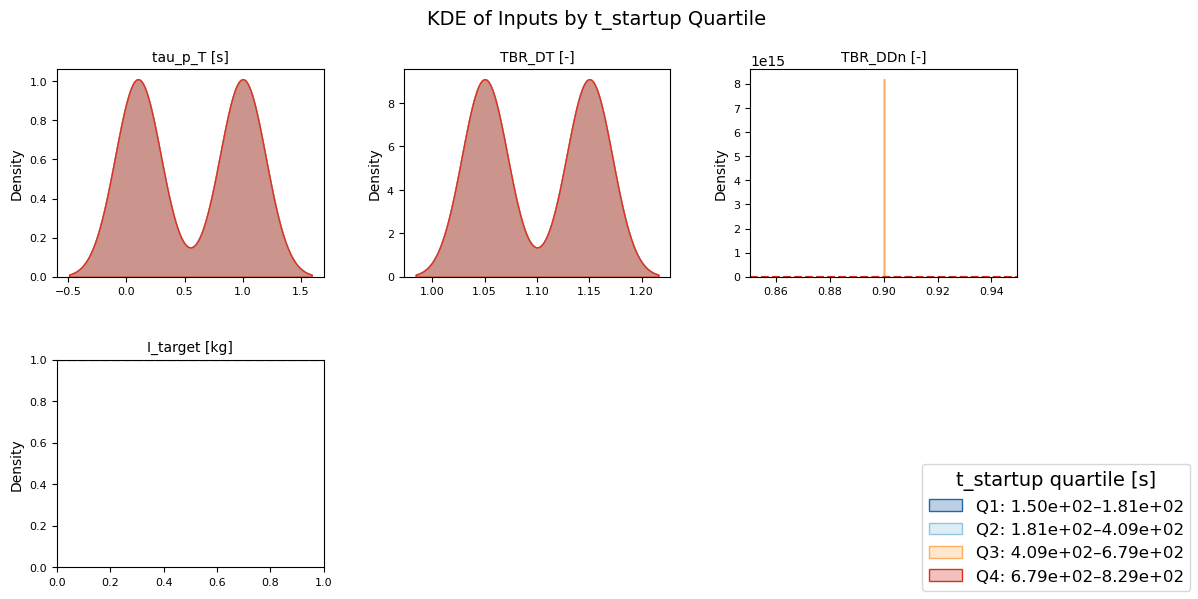

✅ Inline plot displayed


In [11]:
# Inline KDE plot with quartile binning
input_parameters = inputs
n_inputs = len(input_parameters)

if n_inputs == 0:
    print("❌ No input parameters found. Skipping plot.")
else:
    ncols = min(3, n_inputs)
    nrows = int(np.ceil(n_inputs / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows), sharey=False)
    axes = axes.flatten() if n_inputs > 1 else [axes]
    
    # Quartile binning
    bin_edges = df[target].quantile([0, 0.25, 0.5, 0.75, 1.0]).values
    bin_labels = [
        f"Q1: {bin_edges[0]:.2e}–{bin_edges[1]:.2e}",
        f"Q2: {bin_edges[1]:.2e}–{bin_edges[2]:.2e}",
        f"Q3: {bin_edges[2]:.2e}–{bin_edges[3]:.2e}",
        f"Q4: {bin_edges[3]:.2e}–{bin_edges[4]:.2e}"
    ]
    df[f"{target}_bin"] = pd.qcut(df[target], q=4, labels=bin_labels)
    
    # Get colors
    colorscale = get_discrete_colorscale(4)
    quartile_colors = [colorscale[i*2][1] for i in range(4)]
    color_map = {label: quartile_colors[i] for i, label in enumerate(bin_labels)}
    
    for i, param in enumerate(input_parameters):
        ax = axes[i]
        for bin_label in df[f"{target}_bin"].cat.categories:
            data = df.loc[df[f"{target}_bin"] == bin_label, param].dropna()
            if len(data) == 0:
                continue
            color = color_map[bin_label]
            if np.var(data) == 0:
                ax.axhline(1, color=color, linestyle='--', label=str(bin_label))
            else:
                sns.kdeplot(data, fill=True, alpha=0.3, ax=ax, label=str(bin_label), color=color)
        
        # Add unit to title
        if param in PARAM_UNITS:
            param_label = f"{param} [{PARAM_UNITS[param]}]"
        else:
            param_label = param
        ax.set_title(param_label, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Density")
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for j in range(n_inputs, len(axes)):
        axes[j].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    target_unit = PARAM_UNITS.get(target, "")
    legend_title = f"{target} quartile [{target_unit}]"
    fig.legend(handles, labels,
                title=legend_title,
                loc='lower right',
                fontsize=12, title_fontsize=14)
    
    # Adjust layout
    fig.suptitle(f"KDE of Inputs by {target} Quartile", fontsize=14)
    plt.subplots_adjust(
        left=0.05,
        right=0.85,
        top=0.88,
        bottom=0.05,
        wspace=0.3,
        hspace=0.4
    )
    
    plt.show()
    print(f"✅ Inline plot displayed")